# Analyse Positon in EuXFEL switchyard

In [1]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis/')

import numpy as _np
import matplotlib.pyplot as _plt
import pymad8 as _m8

import XFEL_BPM
import loadXFELdata
import plotXFELdata

initializing ocelot...


### Date and save prefix

In [2]:
date = "2026_07_07"
save_name_prefix = "jupyter_notebooks/plots/EUXFEL/Position/" + date + "_EuXFEL_plot"

## Load data file

In [3]:
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file114155_20231120T155943.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file109482_20231119T155947.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file118300_20231121T155956.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file122942_20231122T155946.all.hdf5'
file = 'XFEL_data/BPM_data/matched_linac_main_run2148_file128226_20231123T155954.all.hdf5'

In [4]:
BPMData = loadXFELdata.XFELdata('XFEL_data/BPM_data/matched_linac_main_run2148_file114155_20231120T155943.all.hdf5', 
                                getPosition=True, getCharge=False, getEnergy=False, getTime=False)

Loaded file 'matched_linac_main_run2148_file114155_20231120T155943.all.hdf5'
Loading 49 bpms, 3391 trains and 2708 bunches in df: |██████████████████████████████████████████████████| 100.0% Complete


In [3]:
df = XFEL_BPM.getH5dataInDF('XFEL_data/BPM_data/matched_linac_main_run2148_file114155_20231120T155943.all.hdf5')

Load matched_linac_main_run2148_file114155_20231120T155943.all.hdf5 | 49 bpms, 3391 trains, 2708 bunches: |██████████████████████████████████████████████████| 100.0% Complete


## Plot hist for specific BPM

-82.69853973388672 -55.7838249206543
141.60243225097656 163.2514190673828


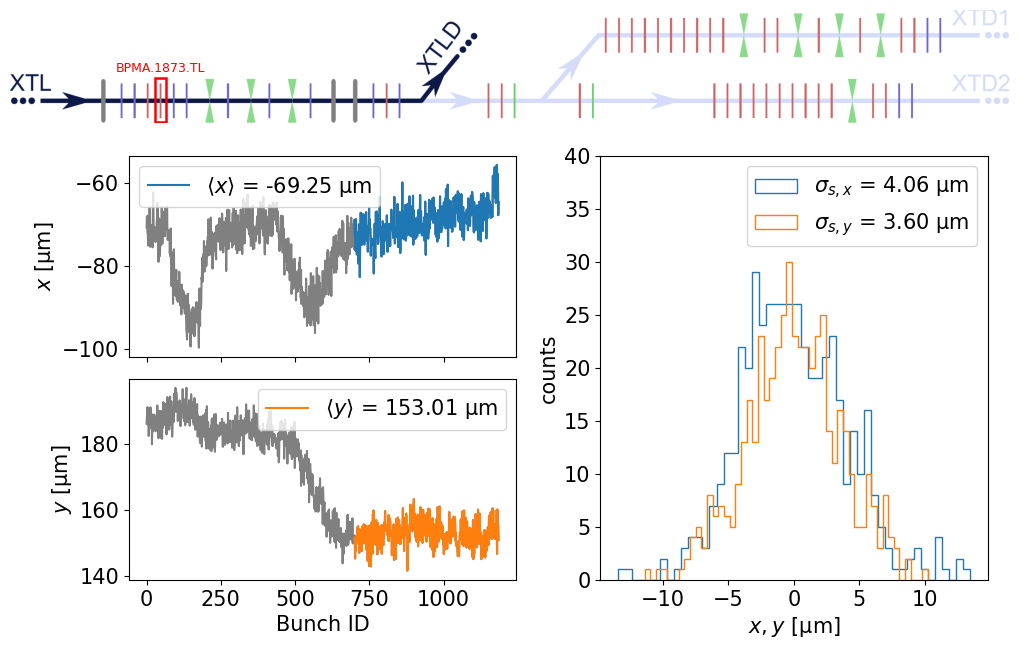

In [4]:
plotXFELdata.PlotAll(df, bpms="BPMA.1873.TL", trains=3, bunches=None, hist_ylim=[0, 40],
                     drawing="../../../Drawings/XS1_diag_XTLD.pdf", arrow_xy=[394, 185, 30, 120],
                     minCut=700, maxCut=2000, figsize=[10, 7])
_plt.savefig("{}_BPM_XTL_per_bunch.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

-96.12417602539062 -52.14397430419922
128.2806396484375 175.29278564453125


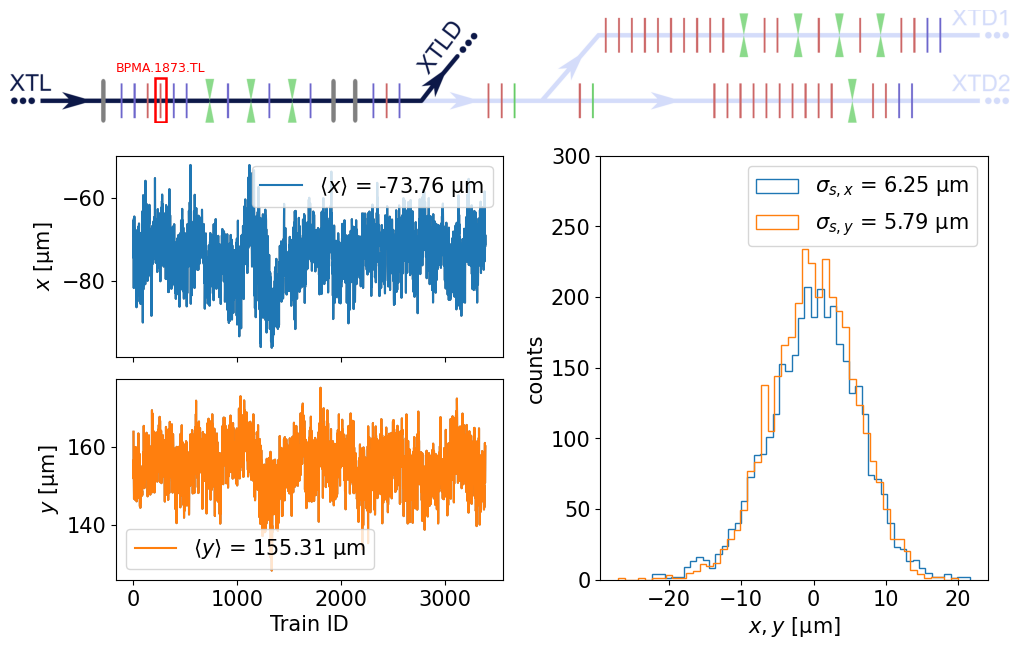

In [5]:
plotXFELdata.PlotAll(df, 
                     # bpms="BPMI.1889.TL", 
                     bpms="BPMA.1873.TL", trains=None, bunches=672, hist_ylim=[0, 300],
                     drawing="../../../Drawings/XS1_diag_XTLD.pdf", arrow_xy=[394, 185, 30, 120],
                     # arrow_xy=[465, 185, 30, 120],
                     minCut=None, maxCut=None, figsize=[10, 7])
_plt.savefig("{}_BPM_XTL_per_train.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

-1289.34912109375 -1263.37158203125
-312.54058837890625 -288.1310119628906


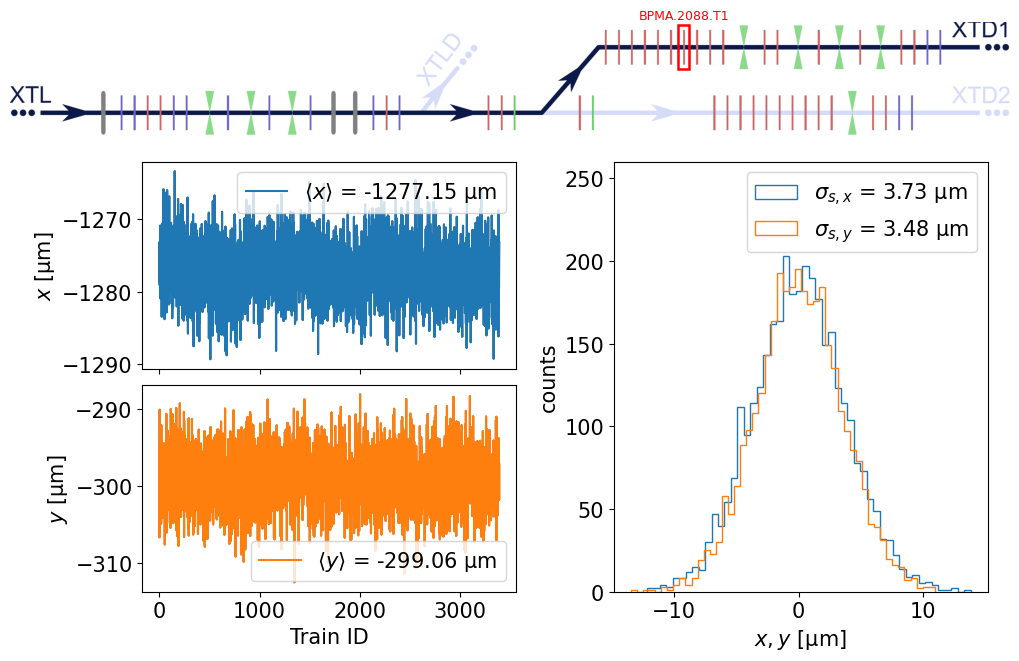

In [6]:
plotXFELdata.PlotAll(df, bpms="BPMA.2088.T1", trains=None, bunches=91, hist_ylim=[0, 260],
                     drawing="../../../Drawings/XS1_diag_XTD1.pdf", arrow_xy=[1817, 9, 30, 120],
                     minCut=None, maxCut=None, figsize=[10, 7])
_plt.savefig("{}_BPM_XTD1_per_train.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

737.817138671875 759.795166015625
397.34503173828125 419.2981872558594


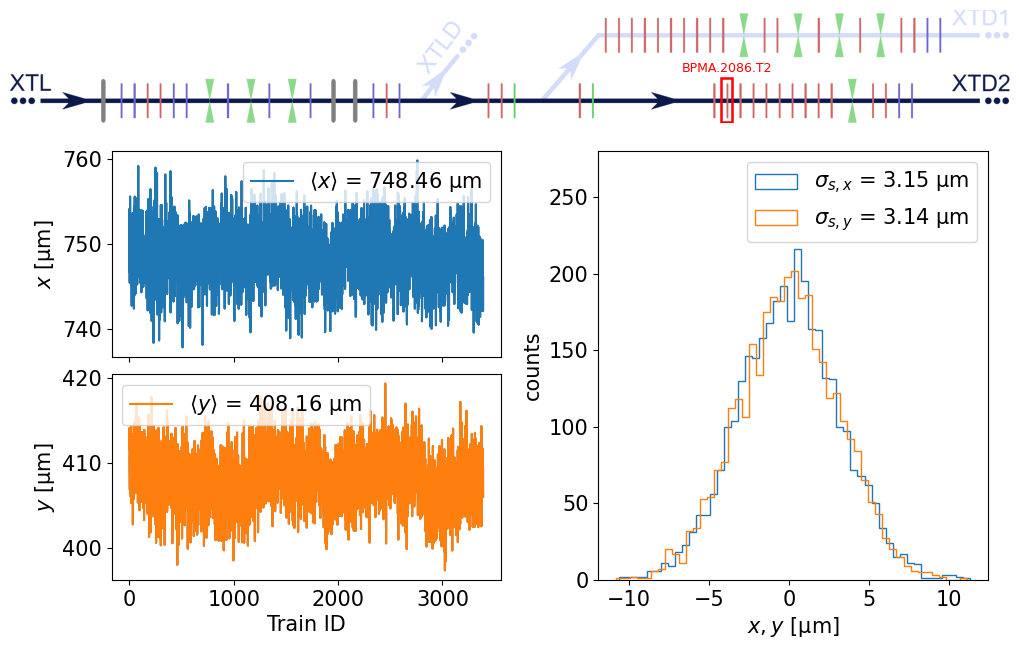

In [7]:
plotXFELdata.PlotAll(df, bpms="BPMA.2086.T2", trains=None, bunches=672, hist_ylim=[0, 280],
                     drawing="../../../Drawings/XS1_diag_XTD2.pdf", arrow_xy=[1934, 185, 30, 120],
                     minCut=None, maxCut=None, figsize=[10, 7])
_plt.savefig("{}_BPM_XTD2_per_train.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

## BPM signal along the lines

In [5]:
df_reduced = BPMData.reduceDFbyBPMTrainBunchByIndex(bpms=None, trains=None, bunches=91)

Mad8.readTwissFile > nrec=8411


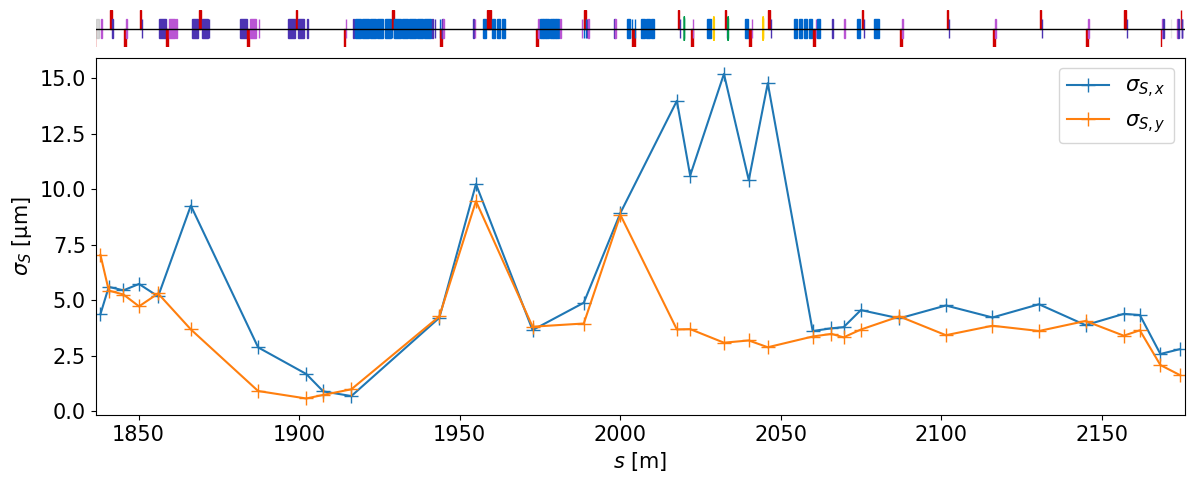

In [6]:
plotXFELdata.plotSignal(BPMData, df_reduced, inSubplots=False, lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 5])
_plt.savefig("{}_BPMs_XTD1_signal.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

Mad8.readTwissFile > nrec=8411


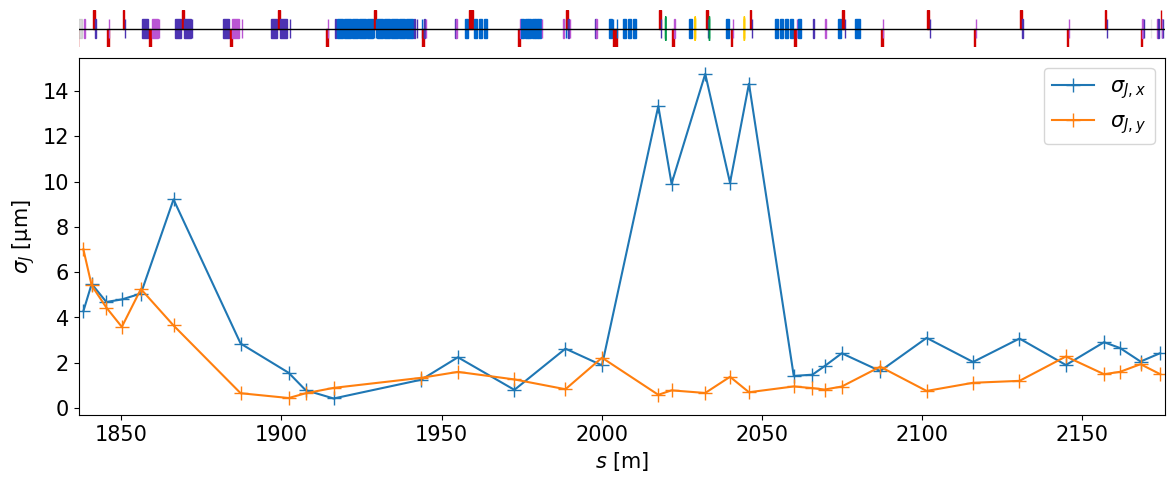

In [7]:
plotXFELdata.plotJitter(BPMData, df_reduced, inSubplots=False, lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 5])
_plt.savefig("{}_BPMs_XTD1_jitter.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

Mad8.readTwissFile > nrec=8411


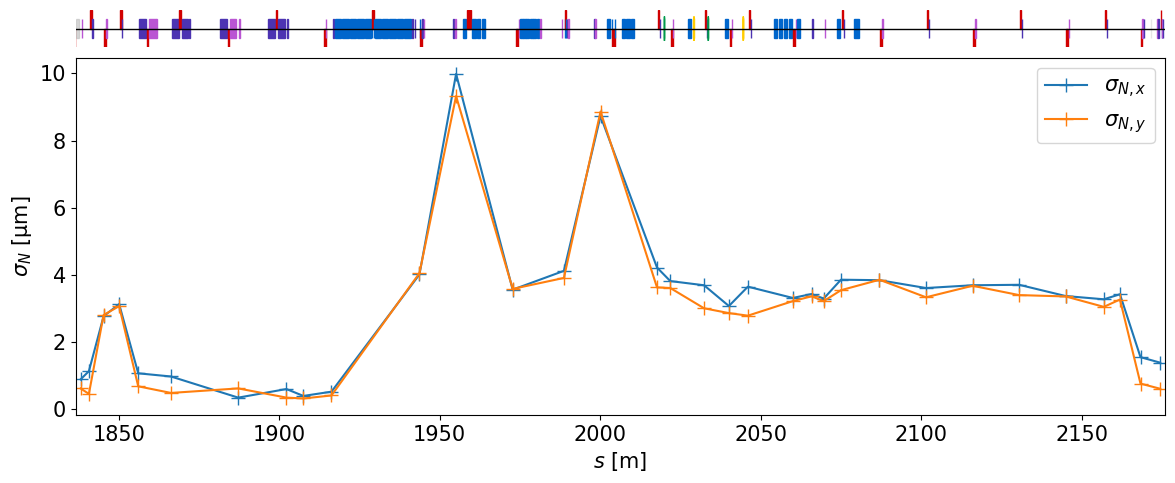

In [8]:
plotXFELdata.plotNoise(BPMData, df_reduced, inSubplots=False, lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 5])
_plt.savefig("{}_BPMs_XTD1_noise.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

Mad8.readTwissFile > nrec=8411


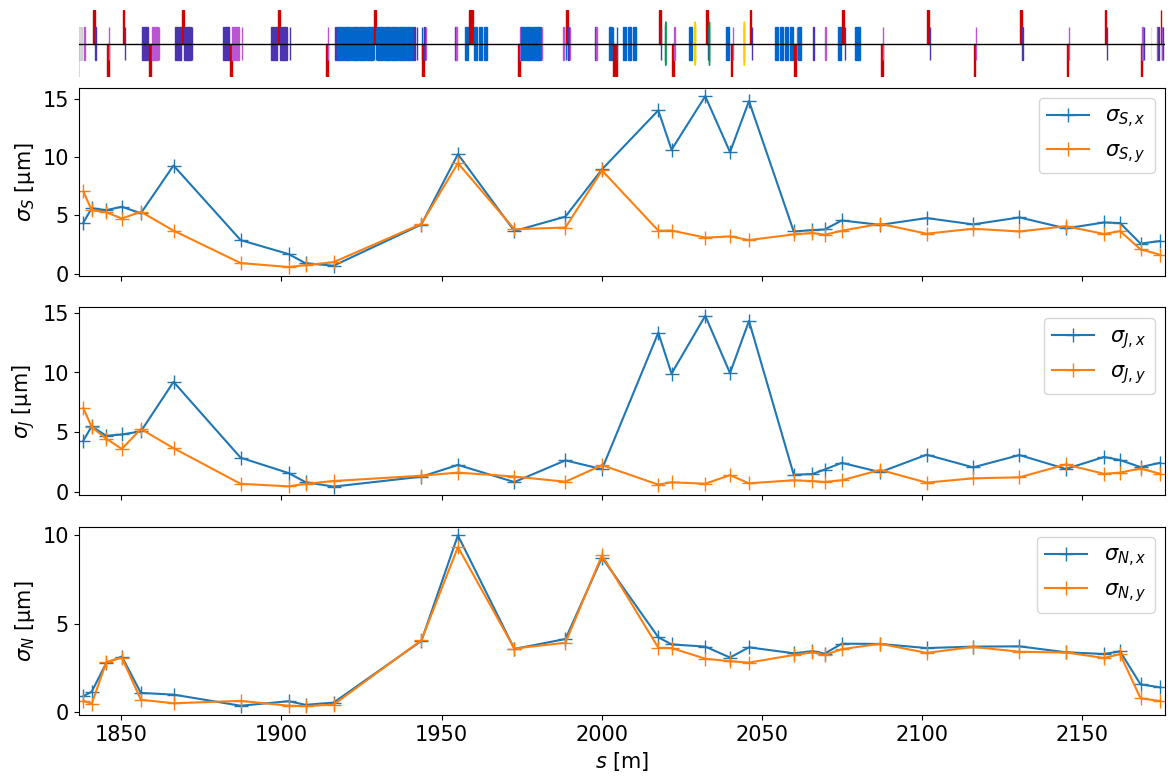

In [9]:
plotXFELdata.plotSignalJitterNoise(BPMData, bpms=None, trains=None, bunches=91, 
                                   lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 8])
_plt.savefig("{}_BPMs_XTD1_signal_jitter_noise.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

Mad8.readTwissFile > nrec=8411


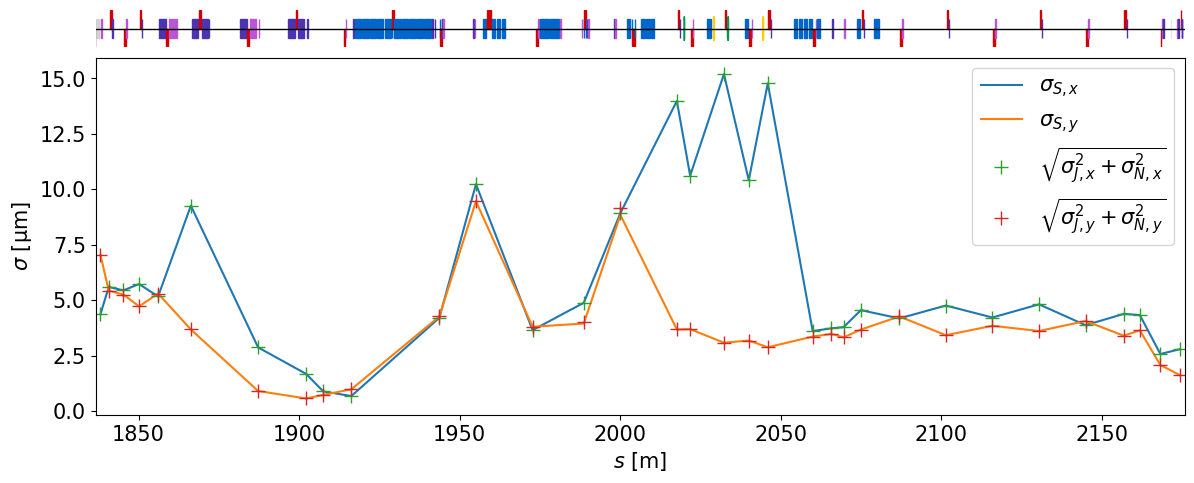

In [10]:
plotXFELdata.plotReconstructSignalAfterSVD(BPMData, df_reduced, 
                                           lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 5])
_plt.savefig("{}_BPMs_XTD1_reconstruction_signal.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

Mad8.readTwissFile > nrec=8411


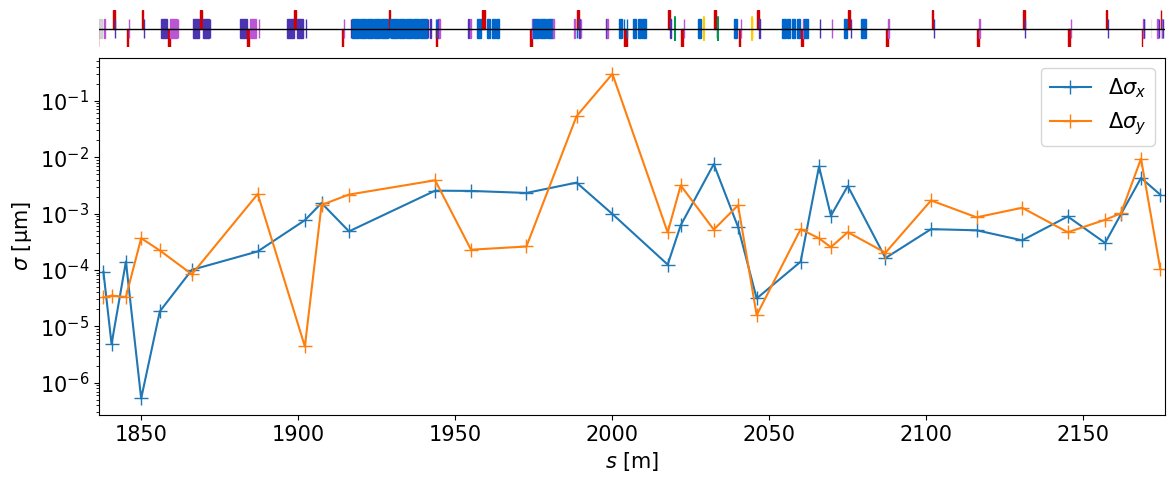

In [6]:
plotXFELdata.plotReconstructSignalSVDDifference(BPMData, df_reduced, 
                                                lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 5])
_plt.savefig("{}_BPMs_XTD1_reconstruction_diff.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

Mad8.readTwissFile > nrec=8411


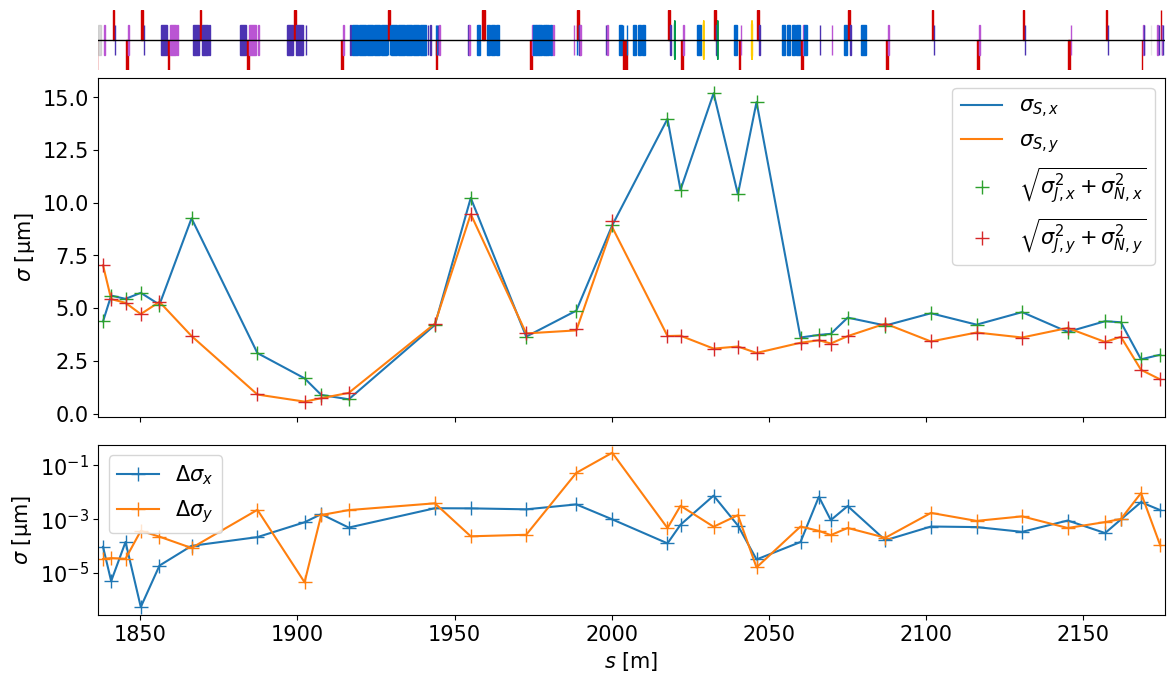

In [12]:
plotXFELdata.plotReconstructionBoth(BPMData, bpms=None, trains=None, bunches=91, 
                                    lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 7])
_plt.savefig("{}_BPMs_XTD1_reconstruction.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

Mad8.readTwissFile > nrec=8411


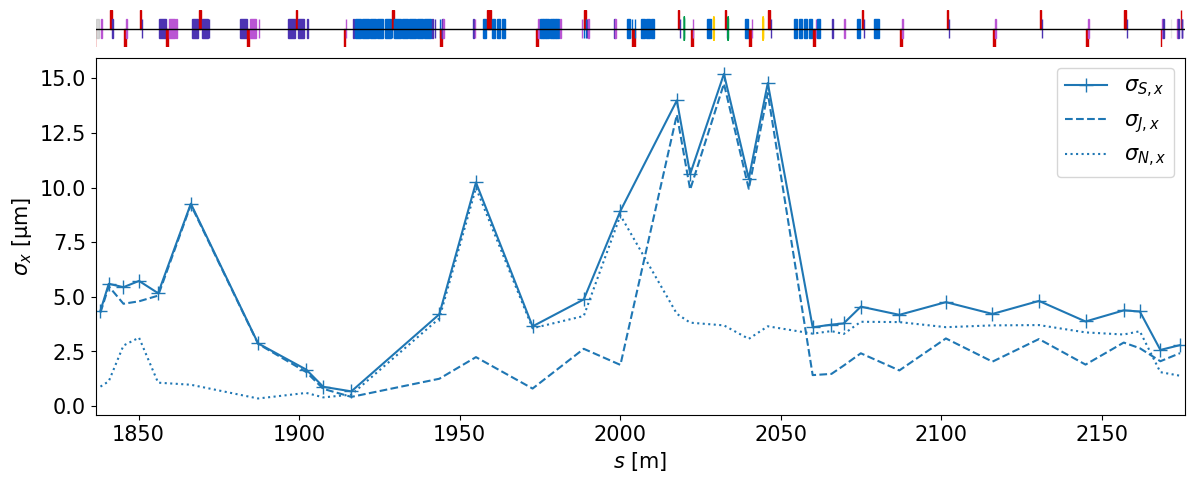

In [13]:
plotXFELdata.plotSignalJitterNoiseX(BPMData, df_reduced, lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 5])

Mad8.readTwissFile > nrec=8411


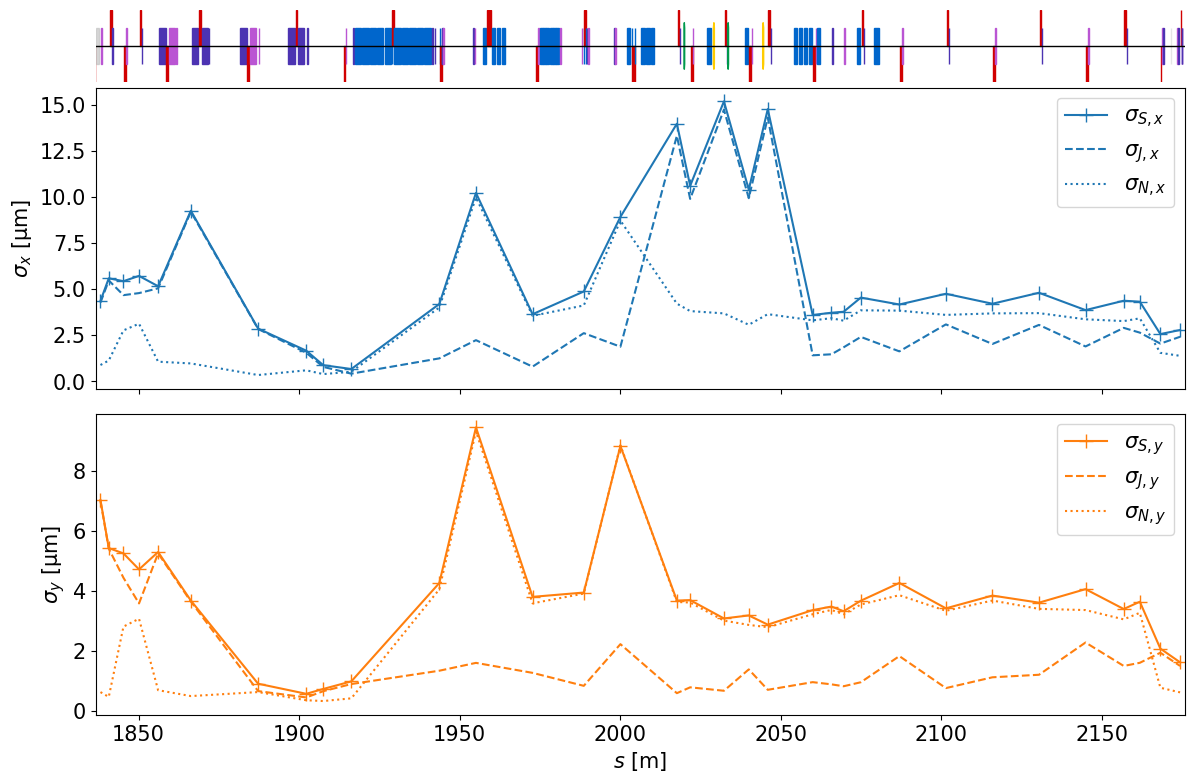

In [14]:
plotXFELdata.plotSignalJitterNoisePerPlane(BPMData, bpms=None, trains=None, bunches=91, 
                                           lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 8])

Mad8.readTwissFile > nrec=8411


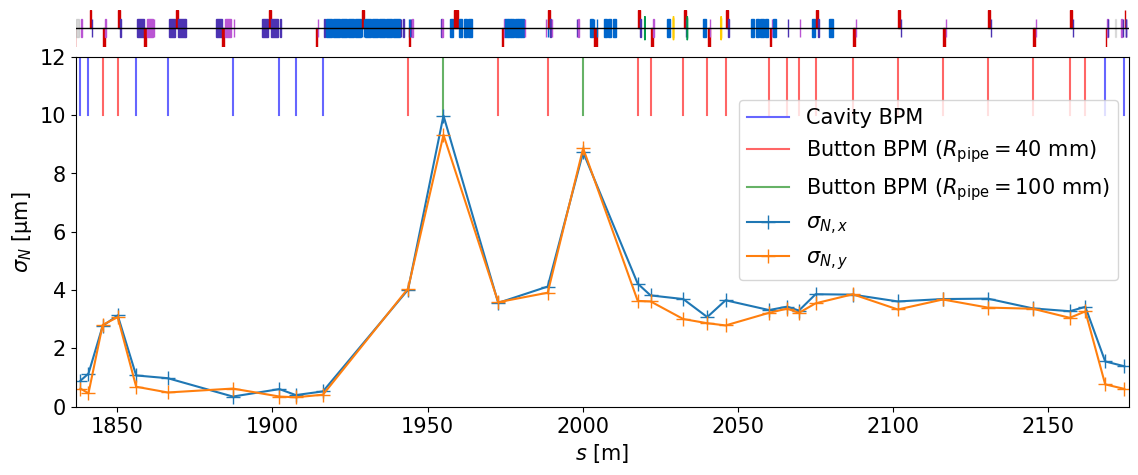

In [6]:
plotXFELdata.plotNoise(BPMData, df_reduced, bpmType=True, inSubplots=False, ylim=[0, 12], legendpos=[0.62, 0.62],
                       lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 5])
_plt.savefig("{}_BPMs_XTD1_noise_with_BPM.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

Mad8.readTwissFile > nrec=8411


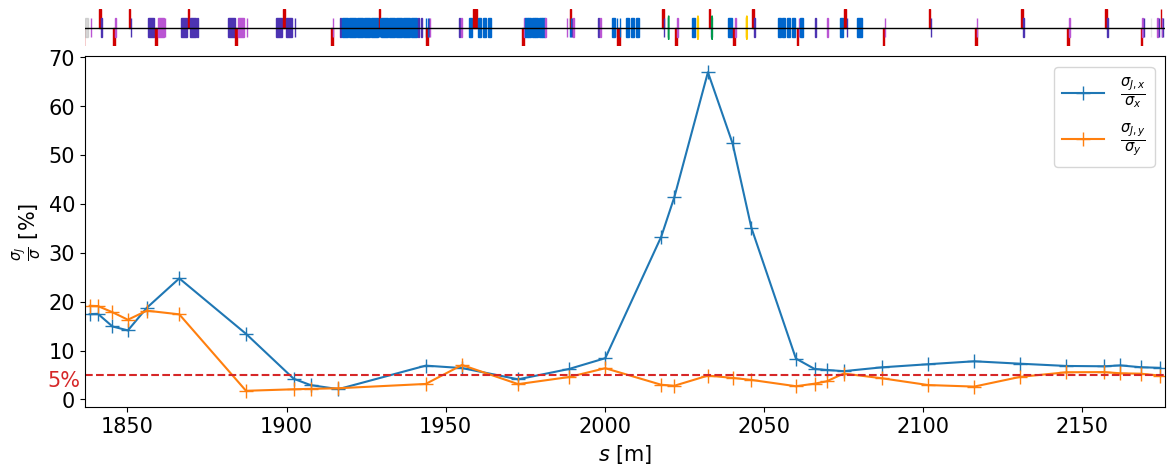

In [6]:
plotXFELdata.plotJitterSigmaRatio(BPMData, df_reduced, inSubplots=False, 
                                  lattice='../01_mad8/XFEL_Lattice_9/TWISS_T5D', figsize=[12, 5])
_plt.savefig("{}_BPMs_XTD1_jitter_sigma_ratio.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

In [3]:
average = loadXFELdata.XFELdata('XFEL_data/BPM_data/matched_linac_main_run2148_file128226_20231123T155954.all.hdf5')

Loaded file 'matched_linac_main_run2148_file128226_20231123T155954.all.hdf5'
Loading 49 bpms, 3180 trains and 2708 bunches in df: |██████████████████████████████████████████████████| 100.0% Complete


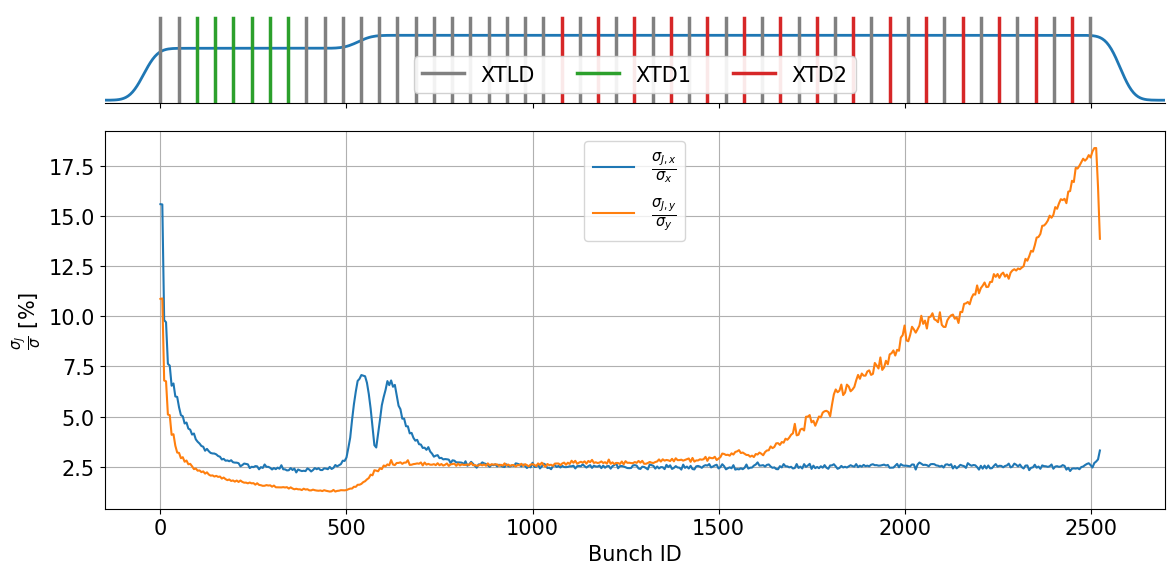

In [4]:
plotXFELdata.plotAverageJitterPerBunchID(average, sample=5, addBunchPattern=True, figsize=[12, 6])
_plt.savefig("{}_BPMs_bunch_jitter_sigma_ratio.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')